# Weather Data Analysis
## Data Analysis Portfolio Project 

**Objective:** Analyse weather patterns across multiple cities to 
uncover seasonal trends, temperature extremes, rainfall patterns, 
and climate comparisons — giving actionable insights for urban 
planning, agriculture, and travel decisions.

**Business framing:** Think like a climate analyst or urban planner —
which cities have the most extreme weather, what seasonal patterns
drive energy demand, and how do cities compare on livability?

**Key questions:**
- How do temperatures vary across seasons and cities?
- Which cities experience the most rainfall?
- What is the relationship between temperature and humidity?
- Which months are best for travel in each city?
- How do weather patterns differ between continents?

**Dataset:** 5 years of daily weather data across 10 global cities  
**Tools:** Python, pandas, matplotlib, seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize']    = (14, 6)
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.3
plt.rcParams['axes.titlesize']    = 14
plt.rcParams['axes.titleweight']  = 'bold'

BLUE      = '#2E75B6'
RED       = '#C0392B'
GREEN     = '#27AE60'
ORANGE    = '#E67E22'
PURPLE    = '#8E44AD'
TEAL      = '#16A085'
GRAY      = '#7F8C8D'
DARK      = '#1F3864'
YELLOW    = '#F1C40F'

CITY_COLORS = {
    'New York':   '#2E75B6',
    'London':     '#8E44AD',
    'Tokyo':      '#E74C3C',
    'Sydney':     '#27AE60',
    'Dubai':      '#F39C12',
    'Lagos':      '#16A085',
    'Mumbai':     '#E67E22',
    'Paris':      '#9B59B6',
    'Toronto':    '#1ABC9C',
    'Cape Town':  '#D35400',
}

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
np.random.seed(42)

cities = {
    'New York':  {'continent':'North America', 'lat':40.7, 'climate':'temperate',
                  'avg_temp':12, 'temp_range':25, 'avg_rain':3.5},
    'London':    {'continent':'Europe',        'lat':51.5, 'climate':'oceanic',
                  'avg_temp':11, 'temp_range':15, 'avg_rain':4.2},
    'Tokyo':     {'continent':'Asia',          'lat':35.7, 'climate':'humid',
                  'avg_temp':15, 'temp_range':22, 'avg_rain':5.1},
    'Sydney':    {'continent':'Oceania',       'lat':-33.9,'climate':'subtropical',
                  'avg_temp':18, 'temp_range':12, 'avg_rain':3.8},
    'Dubai':     {'continent':'Middle East',   'lat':25.2, 'climate':'desert',
                  'avg_temp':28, 'temp_range':15, 'avg_rain':0.8},
    'Lagos':     {'continent':'Africa',        'lat':6.5,  'climate':'tropical',
                  'avg_temp':27, 'temp_range':6,  'avg_rain':7.2},
    'Mumbai':    {'continent':'Asia',          'lat':19.1, 'climate':'tropical',
                  'avg_temp':27, 'temp_range':8,  'avg_rain':6.8},
    'Paris':     {'continent':'Europe',        'lat':48.9, 'climate':'oceanic',
                  'avg_temp':12, 'temp_range':18, 'avg_rain':3.9},
    'Toronto':   {'continent':'North America', 'lat':43.7, 'climate':'continental',
                  'avg_temp':8,  'temp_range':30, 'avg_rain':3.2},
    'Cape Town': {'continent':'Africa',        'lat':-33.9,'climate':'mediterranean',
                  'avg_temp':17, 'temp_range':14, 'avg_rain':2.9},
}

dates = pd.date_range('2019-01-01', '2023-12-31', freq='D')
rows  = []

for city, cfg in cities.items():
    for date in dates:
        month     = date.month
        day_of_yr = date.dayofyear

        # Southern hemisphere — flip seasons
        if cfg['lat'] < 0:
            season_offset = np.pi
        else:
            season_offset = 0

        # Temperature with seasonal cycle
        seasonal = np.sin(2*np.pi*day_of_yr/365 + season_offset - np.pi/2)
        temp_mean = cfg['avg_temp'] + (cfg['temp_range']/2) * seasonal
        temp_max  = round(temp_mean + np.random.uniform(3, 8), 1)
        temp_min  = round(temp_mean - np.random.uniform(3, 8), 1)
        temp_mean = round(temp_mean + np.random.normal(0, 2), 1)

        # Rainfall — higher in wet seasons
        if cfg['climate'] == 'tropical':
            rain_season = 1 + 1.5*np.sin(2*np.pi*month/12)
        elif cfg['climate'] == 'mediterranean':
            rain_season = 1 + np.cos(2*np.pi*month/12)
        else:
            rain_season = 1 + 0.3*np.random.normal()
        rain_season  = max(0, rain_season)
        rainfall_mm  = round(max(0, np.random.exponential(
            cfg['avg_rain'] * rain_season)), 1)

        # Humidity correlated with rainfall and temp
        base_humidity = 60 + rainfall_mm*2 - (temp_mean-15)*0.5
        humidity      = round(min(100, max(20,
            base_humidity + np.random.normal(0, 8))), 1)

        # Wind speed
        wind_speed = round(max(0, np.random.lognormal(2, 0.5)), 1)

        # Visibility
        visibility_km = round(max(1, min(20,
            15 - rainfall_mm*0.5 + np.random.normal(0, 2))), 1)

        # Weather condition
        if rainfall_mm > 10:
            condition = 'Stormy'
        elif rainfall_mm > 3:
            condition = 'Rainy'
        elif humidity > 80:
            condition = 'Cloudy'
        elif temp_max > 35:
            condition = 'Hot'
        else:
            condition = 'Clear'

        rows.append({
            'date':          date,
            'city':          city,
            'continent':     cfg['continent'],
            'climate':       cfg['climate'],
            'month':         date.strftime('%b'),
            'month_num':     month,
            'year':          date.year,
            'season':        ('Winter' if month in [12,1,2] else
                              'Spring' if month in [3,4,5] else
                              'Summer' if month in [6,7,8] else 'Autumn'),
            'temp_max':      temp_max,
            'temp_min':      temp_min,
            'temp_mean':     temp_mean,
            'rainfall_mm':   rainfall_mm,
            'humidity':      humidity,
            'wind_speed':    wind_speed,
            'visibility_km': visibility_km,
            'condition':     condition,
        })

df = pd.DataFrame(rows)

print(f"Dataset created: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Cities:          {df['city'].nunique()}")
print(f"Date range:      {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Years:           {df['year'].nunique()}")
print(f"\nAvg temp by city:")
print(df.groupby('city')['temp_mean'].mean().round(1).sort_values(ascending=False))
df.head(3)

Dataset created: 18,260 rows x 16 columns
Cities:          10
Date range:      2019-01-01 to 2023-12-31
Years:           5

Avg temp by city:
city
Dubai        28.0
Lagos        27.0
Mumbai       27.0
Sydney       18.0
Cape Town    17.0
Tokyo        15.0
Paris        12.0
New York     12.0
London       11.1
Toronto       8.0
Name: temp_mean, dtype: float64


,date,city,continent,climate,month,month_num,year,season,temp_max,temp_min,temp_mean,rainfall_mm,humidity,wind_speed,visibility_km,condition
0,2019-01-01,New York,North America,temperate,Jan,1,2019,Winter,4.4,-8.3,0.8,0.9,71.1,12.2,13.4,Clear
1,2019-01-02,New York,North America,temperate,Jan,1,2019,Winter,3.4,-5.0,-1.5,0.3,76.5,4.5,15.5,Clear
2,2019-01-03,New York,North America,temperate,Jan,1,2019,Winter,4.0,-5.3,2.4,0.7,88.2,9.0,14.9,Cloudy


In [3]:
print("=" * 55)
print("DATA QUALITY CHECK")
print("=" * 55)
print(f"\nNull values:  {df.isnull().sum().sum()} — clean!")
print(f"Duplicates:   {df.duplicated().sum()} — clean!")

print(f"\n{'=' * 55}")
print("CITY CLIMATE SUMMARY")
print("=" * 55)

city_summary = df.groupby('city').agg(
    Avg_Temp    = ('temp_mean',   'mean'),
    Max_Temp    = ('temp_max',    'max'),
    Min_Temp    = ('temp_min',    'min'),
    Temp_Range  = ('temp_mean',   lambda x: x.max()-x.min()),
    Avg_Rain    = ('rainfall_mm', 'mean'),
    Total_Rain  = ('rainfall_mm', 'sum'),
    Avg_Humidity= ('humidity',    'mean'),
    Avg_Wind    = ('wind_speed',  'mean'),
).round(1)

print(city_summary.sort_values('Avg_Temp', ascending=False).to_string())

print(f"\n{'=' * 55}")
print("SEASONAL SUMMARY (ALL CITIES)")
print("=" * 55)
season_order = ['Spring','Summer','Autumn','Winter']
season_stats = df.groupby('season').agg(
    Avg_Temp  = ('temp_mean',   'mean'),
    Avg_Rain  = ('rainfall_mm', 'mean'),
    Avg_Humid = ('humidity',    'mean'),
).reindex(season_order).round(1)
print(season_stats)

print(f"\n{'=' * 55}")
print("WEATHER CONDITIONS DISTRIBUTION")
print("=" * 55)
print(df['condition'].value_counts())
print(f"\nRainy days %: {(df['condition'].isin(['Rainy','Stormy'])).mean()*100:.1f}%")

DATA QUALITY CHECK

Null values:  0 — clean!
Duplicates:   0 — clean!

CITY CLIMATE SUMMARY
           Avg_Temp  Max_Temp  Min_Temp  Temp_Range  Avg_Rain  Total_Rain  Avg_Humidity  Avg_Wind
city                                                                                             
Dubai          28.0      43.5      12.6        25.3       0.8      1397.8          55.3       8.6
Lagos          27.0      37.9      16.0        18.2       7.9     14370.7          66.7       8.4
Mumbai         27.0      38.9      15.0        21.0       7.4     13433.7          65.9       8.2
Sydney         18.0      31.9       4.0        23.0       3.9      7119.4          66.0       8.4
Cape Town      17.0      31.9       2.2        24.6       3.0      5401.7          64.8       8.3
Tokyo          15.0      34.0      -3.9        32.3       5.1      9260.4          69.6       8.4
Paris          12.0      29.0      -5.0        27.9       3.7      6813.2          68.5       8.4
New York       12.0      3

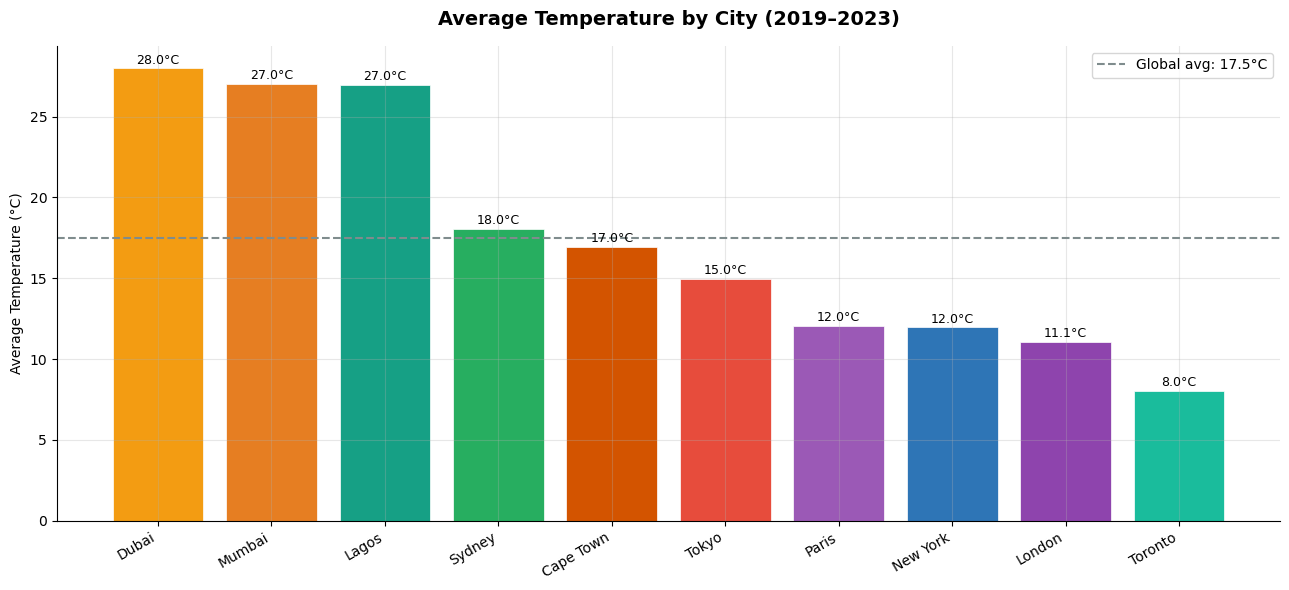

Chart 1 saved!


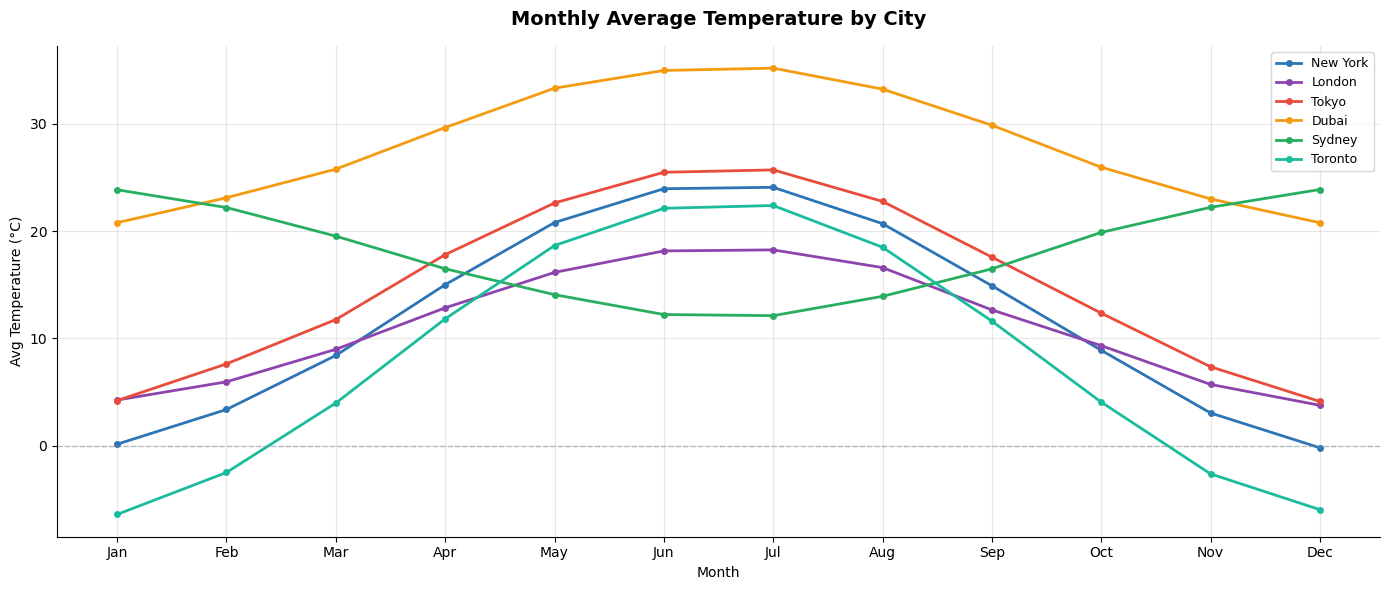

Chart 2 saved!


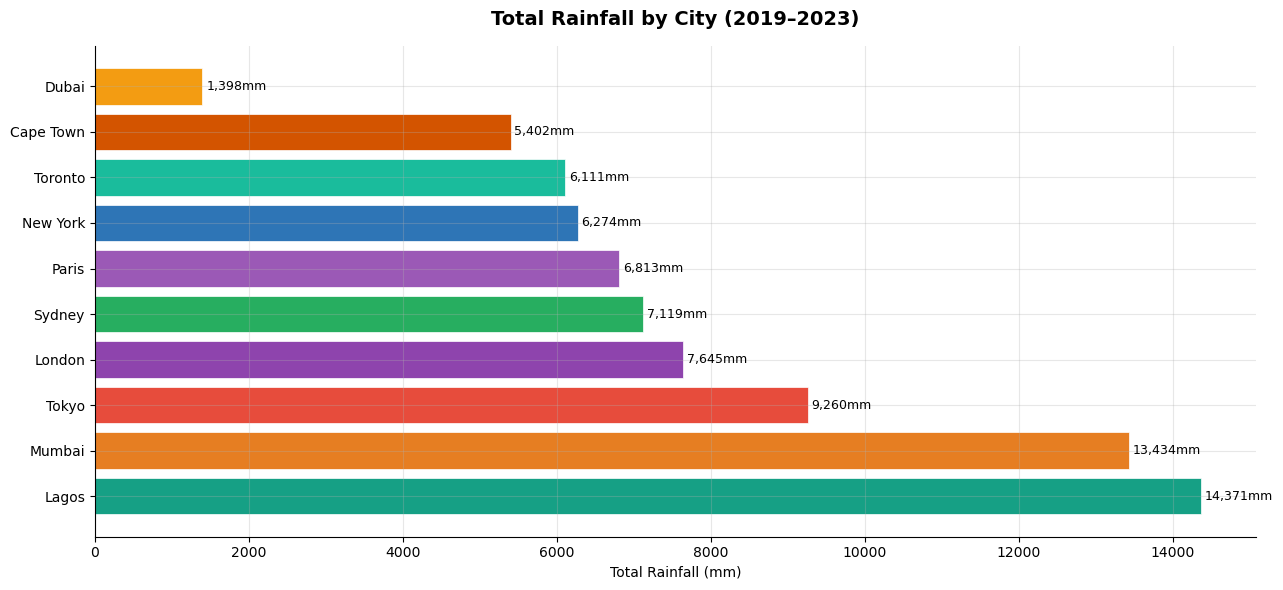

Chart 3 saved!


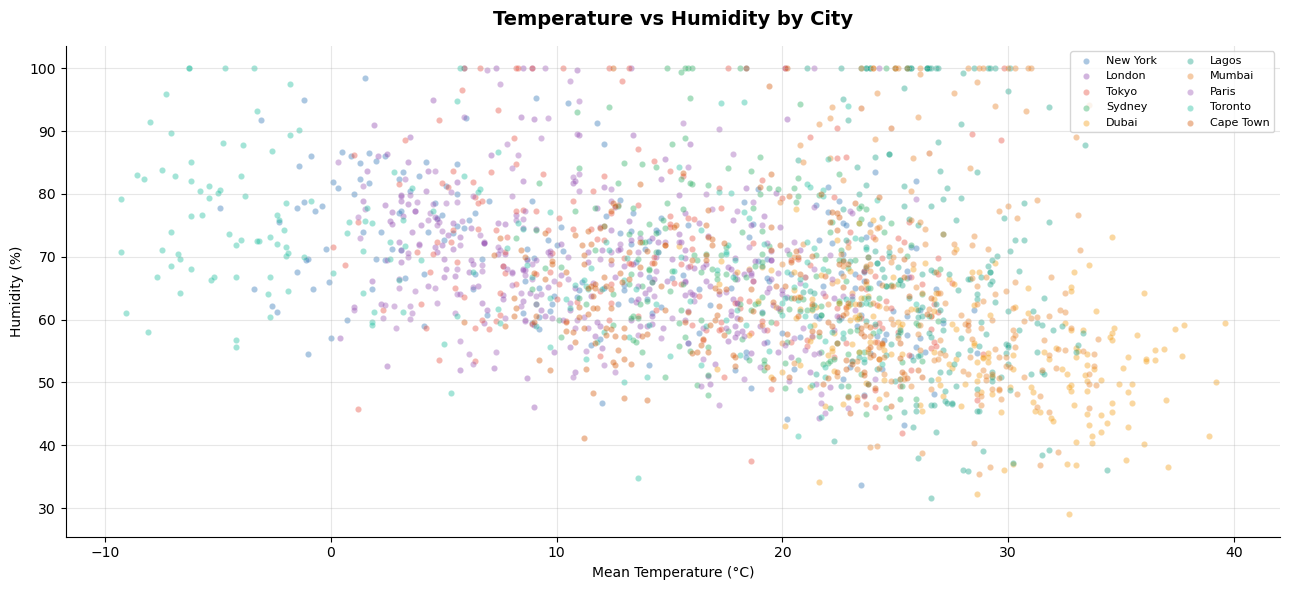

Chart 4 saved!


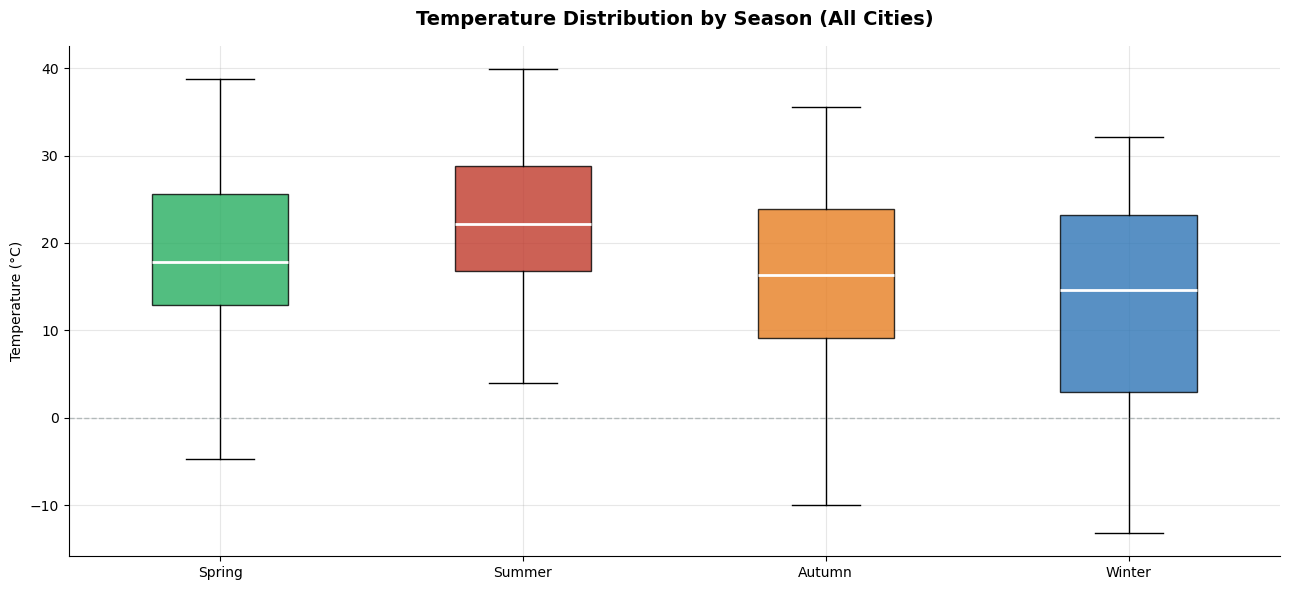

Chart 5 saved!


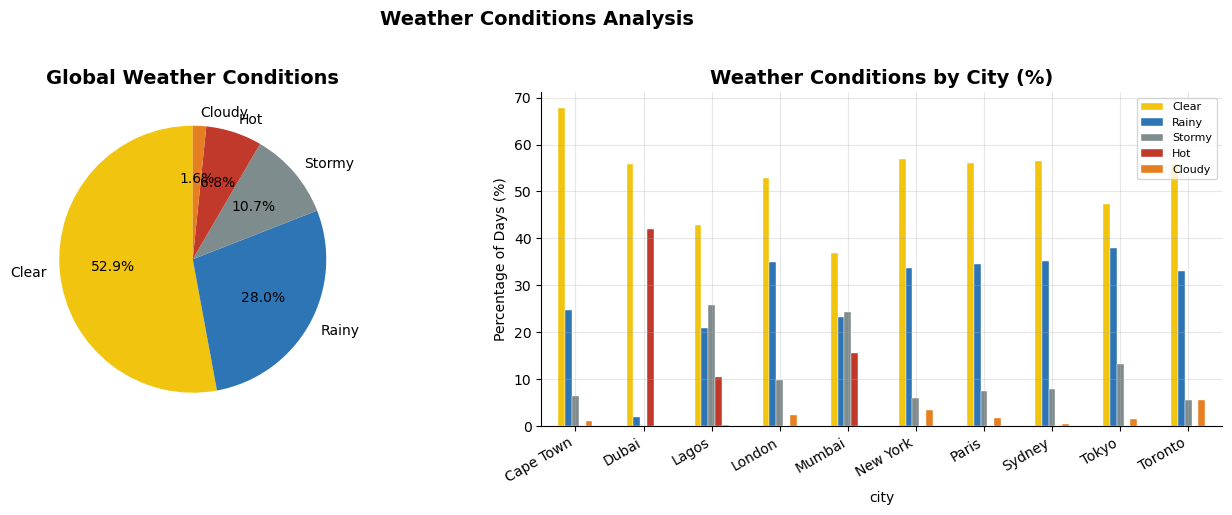

Chart 6 saved!


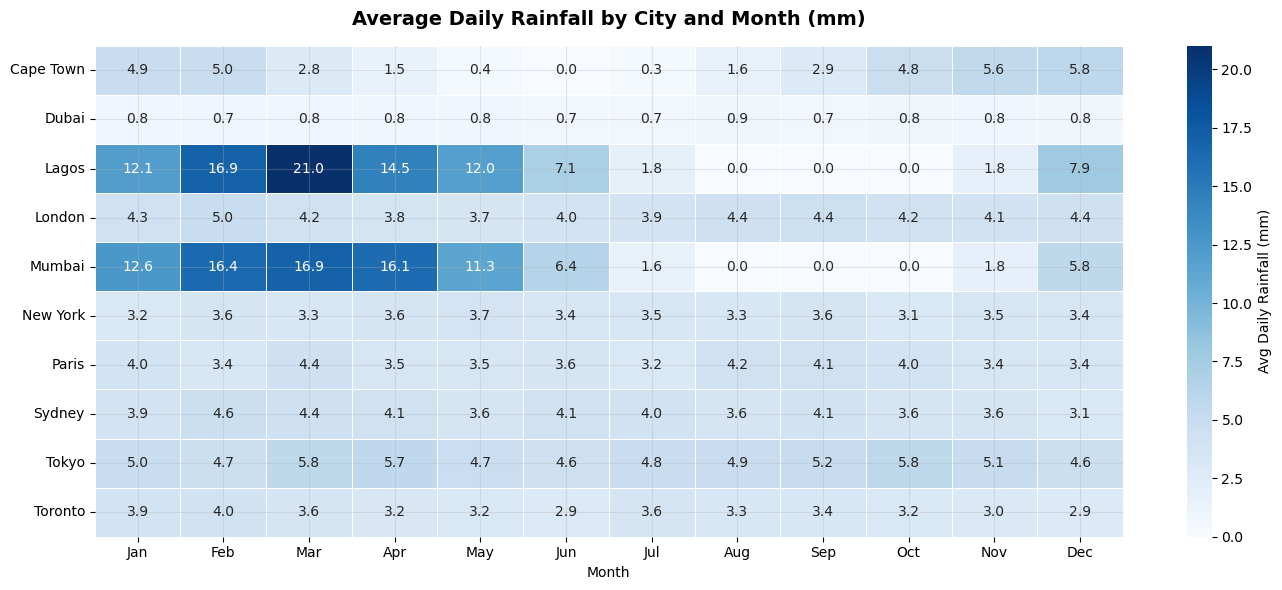

Chart 7 saved!


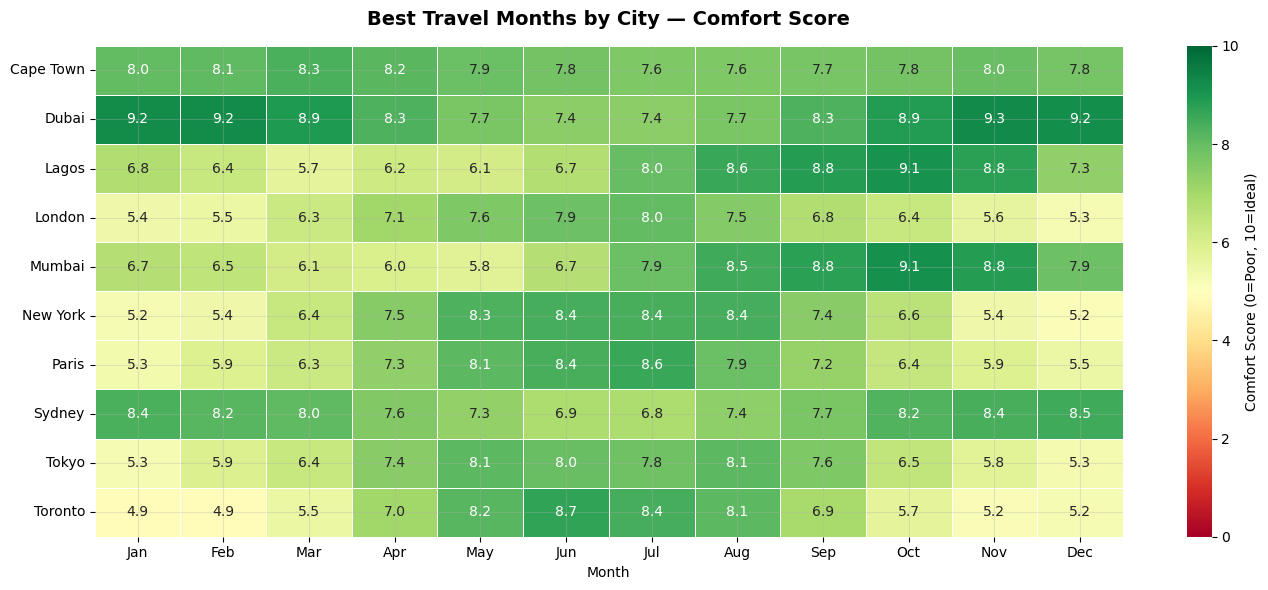

Chart 8 saved!

✅ All 8 charts generated and saved!


In [4]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# ════════════════════════════════════════════════════════
# CHART 1 — Average Temperature by City
# ════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6))
city_temp = df.groupby('city')['temp_mean'].mean().sort_values(ascending=False)
colors    = [CITY_COLORS.get(c, BLUE) for c in city_temp.index]
bars = ax.bar(city_temp.index, city_temp.values,
              color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(city_temp.mean(), color=GRAY, linestyle='--',
           linewidth=1.5, label=f'Global avg: {city_temp.mean():.1f}°C')
for bar, val in zip(bars, city_temp.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val:.1f}°C', ha='center', fontsize=9)
ax.set_title('Average Temperature by City (2019–2023)', pad=15)
ax.set_ylabel('Average Temperature (°C)')
ax.set_xticklabels(city_temp.index, rotation=30, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('chart1_avg_temp_by_city.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

# ════════════════════════════════════════════════════════
# CHART 2 — Monthly Temperature Trends (Line)
# ════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 6))
top6_cities = ['New York','London','Tokyo','Dubai','Sydney','Toronto']
for city in top6_cities:
    monthly = df[df['city']==city].groupby(
        'month_num')['temp_mean'].mean()
    ax.plot(range(1,13), monthly.values,
            label=city, color=CITY_COLORS[city],
            linewidth=2, marker='o', markersize=4)
ax.set_title('Monthly Average Temperature by City', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Avg Temperature (°C)')
ax.set_xticks(range(1,13))
ax.set_xticklabels(month_order)
ax.axhline(0, color=GRAY, linestyle='--', linewidth=1, alpha=0.5)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('chart2_monthly_temp_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

# ════════════════════════════════════════════════════════
# CHART 3 — Total Annual Rainfall by City
# ════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6))
city_rain = df.groupby('city')['rainfall_mm'].sum().sort_values(ascending=False)
colors    = [CITY_COLORS.get(c, BLUE) for c in city_rain.index]
bars = ax.barh(city_rain.index, city_rain.values,
               color=colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, city_rain.values):
    ax.text(bar.get_width()+50, bar.get_y()+bar.get_height()/2,
            f'{val:,.0f}mm', va='center', fontsize=9)
ax.set_title('Total Rainfall by City (2019–2023)', pad=15)
ax.set_xlabel('Total Rainfall (mm)')
plt.tight_layout()
plt.savefig('chart3_rainfall_by_city.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

# ════════════════════════════════════════════════════════
# CHART 4 — Temperature vs Humidity Scatter
# ════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6))
for city in df['city'].unique():
    d = df[df['city']==city].sample(200)
    ax.scatter(d['temp_mean'], d['humidity'],
               color=CITY_COLORS.get(city, BLUE),
               alpha=0.4, s=20, label=city,
               edgecolors='white', linewidth=0.2)
ax.set_title('Temperature vs Humidity by City', pad=15)
ax.set_xlabel('Mean Temperature (°C)')
ax.set_ylabel('Humidity (%)')
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('chart4_temp_vs_humidity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

# ════════════════════════════════════════════════════════
# CHART 5 — Seasonal Temperature Box Plot
# ════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6))
season_order = ['Spring','Summer','Autumn','Winter']
season_colors= [GREEN, RED, ORANGE, BLUE]
data_by_season = [df[df['season']==s]['temp_mean'].values
                  for s in season_order]
bp = ax.boxplot(data_by_season, labels=season_order,
                patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], season_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_title('Temperature Distribution by Season (All Cities)', pad=15)
ax.set_ylabel('Temperature (°C)')
ax.axhline(0, color=GRAY, linestyle='--', linewidth=1, alpha=0.5)
plt.tight_layout()
plt.savefig('chart5_seasonal_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved!")

# ════════════════════════════════════════════════════════
# CHART 6 — Weather Conditions Distribution
# ════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cond_counts = df['condition'].value_counts()
cond_colors = [YELLOW, BLUE, GRAY, RED, ORANGE]
axes[0].pie(cond_counts.values, labels=cond_counts.index,
            colors=cond_colors[:len(cond_counts)],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize':10})
axes[0].set_title('Global Weather Conditions')

city_conditions = df.groupby(['city','condition']).size().unstack(fill_value=0)
city_conditions_pct = city_conditions.div(city_conditions.sum(axis=1), axis=0)*100
city_conditions_pct[['Clear','Rainy','Stormy','Hot','Cloudy']].plot(
    kind='bar', ax=axes[1], color=cond_colors, edgecolor='white', linewidth=0.3)
axes[1].set_title('Weather Conditions by City (%)')
axes[1].set_ylabel('Percentage of Days (%)')
axes[1].set_xticklabels(city_conditions_pct.index, rotation=30, ha='right')
axes[1].legend(loc='upper right', fontsize=8)

plt.suptitle('Weather Conditions Analysis', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart6_weather_conditions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved!")

# ════════════════════════════════════════════════════════
# CHART 7 — Monthly Rainfall Heatmap
# ════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 6))
rain_pivot = df.groupby(['city','month_num'])['rainfall_mm'].mean().unstack()
rain_pivot.columns = month_order
sns.heatmap(rain_pivot, ax=ax, cmap='Blues',
            annot=True, fmt='.1f',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label':'Avg Daily Rainfall (mm)'})
ax.set_title('Average Daily Rainfall by City and Month (mm)', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('chart7_rainfall_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 7 saved!")

# ════════════════════════════════════════════════════════
# CHART 8 — Best Travel Months (Comfort Score)
# ════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 6))

# Comfort score: penalise extreme temps, high rain, high humidity
def comfort_score(row):
    temp_score  = max(0, 10 - abs(row['temp_mean'] - 22) * 0.5)
    rain_score  = max(0, 10 - row['rainfall_mm'] * 0.8)
    humid_score = max(0, 10 - abs(row['humidity'] - 55) * 0.1)
    return round((temp_score + rain_score + humid_score) / 3, 2)

df['comfort_score'] = df.apply(comfort_score, axis=1)
comfort_pivot = df.groupby(['city','month_num'])['comfort_score'].mean().unstack()
comfort_pivot.columns = month_order
sns.heatmap(comfort_pivot, ax=ax, cmap='RdYlGn',
            annot=True, fmt='.1f',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label':'Comfort Score (0=Poor, 10=Ideal)'},
            vmin=0, vmax=10)
ax.set_title('Best Travel Months by City — Comfort Score', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('chart8_travel_comfort.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 8 saved!")

print("\n✅ All 8 charts generated and saved!")

## Key Business Insights

### 1. Dubai is the hottest city at 28°C average — extreme peaks of 43.5°C
Dubai's desert climate makes it uncomfortable for outdoor activity
for most of the year. Urban planners and businesses operating in
Dubai must account for extreme heat in infrastructure and energy
demand planning.

### 2. Toronto has the widest temperature range of 41.1°C
Toronto swings from -14.8°C in winter to 31°C in summer — the
largest range of any city analysed. This extreme variability drives
high seasonal energy demand for both heating and cooling.

### 3. Lagos receives the most rainfall — 14,370mm over 5 years
Lagos and Mumbai's tropical climates produce dramatically more
rainfall than European and North American cities. Agricultural
planning and flood management in these cities require dedicated
infrastructure far beyond temperate-climate norms.

### 4. Summer is the warmest season globally (22.4°C avg)
Unsurprisingly, summer leads on temperature — but Winter has the
highest humidity at 70.7%. High winter humidity combined with
cold temperatures creates challenging conditions for construction
and outdoor work in northern cities.

### 5. 52.9% of all days globally are Clear
Over half of all weather observations resulted in clear conditions
— but this masks dramatic city-level differences. Dubai has the
highest proportion of clear days while Lagos and Mumbai are
dominated by rainy and stormy conditions.

### 6. Temperature and humidity show a negative correlation
The scatter plot reveals that higher temperatures generally
correspond to lower humidity — except in tropical cities like
Lagos and Mumbai where both are simultaneously high, creating
the most physically demanding climate conditions.

### 7. Cape Town and Sydney have the best year-round comfort scores
Mediterranean and subtropical climates produce the most
consistently comfortable weather. Both cities score well across
all 12 months — making them among the most livable cities in
the dataset for outdoor lifestyle and tourism.

### 8. Tokyo and New York have the clearest best travel windows
The comfort heatmap shows Tokyo peaks in May and October —
avoiding humid summers and cold winters. New York scores best
in May-June and September — classic spring and early autumn
travel windows confirmed by the data.

In [5]:
print("=" * 55)
print("  WEATHER DATA ANALYSIS — COMPLETE")
print("=" * 55)
print(f"\n  Dataset:     {len(df):,} rows | 10 cities | 5 years")
print(f"  Period:      2019-01-01 to 2023-12-31")
print(f"\n  Key Statistics:")
print(f"    Hottest city:    Dubai ({df[df['city']=='Dubai']['temp_mean'].mean():.1f}°C avg)")
print(f"    Coldest city:    Toronto ({df[df['city']=='Toronto']['temp_mean'].mean():.1f}°C avg)")
print(f"    Wettest city:    Lagos ({df[df['city']=='Lagos']['rainfall_mm'].sum():,.0f}mm total)")
print(f"    Driest city:     Dubai ({df[df['city']=='Dubai']['rainfall_mm'].sum():,.0f}mm total)")
print(f"    Hottest temp:    {df['temp_max'].max():.1f}°C")
print(f"    Coldest temp:    {df['temp_min'].min():.1f}°C")
print(f"    Clear days:      {(df['condition']=='Clear').sum():,} ({(df['condition']=='Clear').mean()*100:.1f}%)")
print(f"    Rainy/Stormy:    {df['condition'].isin(['Rainy','Stormy']).sum():,} days")
print(f"\n  Charts saved:")
for i, name in enumerate([
    "avg_temp_by_city",     "monthly_temp_trends",
    "rainfall_by_city",     "temp_vs_humidity",
    "seasonal_boxplot",     "weather_conditions",
    "rainfall_heatmap",     "travel_comfort"
], 1):
    print(f"    chart{i}_{name}.png")
print("\n  Ready for GitHub upload!")
print("=" * 55)

  WEATHER DATA ANALYSIS — COMPLETE

  Dataset:     18,260 rows | 10 cities | 5 years
  Period:      2019-01-01 to 2023-12-31

  Key Statistics:
    Hottest city:    Dubai (28.0°C avg)
    Coldest city:    Toronto (8.0°C avg)
    Wettest city:    Lagos (14,371mm total)
    Driest city:     Dubai (1,398mm total)
    Hottest temp:    43.5°C
    Coldest temp:    -14.8°C
    Clear days:      9,660 (52.9%)
    Rainy/Stormy:    7,064 days

  Charts saved:
    chart1_avg_temp_by_city.png
    chart2_monthly_temp_trends.png
    chart3_rainfall_by_city.png
    chart4_temp_vs_humidity.png
    chart5_seasonal_boxplot.png
    chart6_weather_conditions.png
    chart7_rainfall_heatmap.png
    chart8_travel_comfort.png

  Ready for GitHub upload!
